# Radio-burst inference: one timestamp in, a forecast out

Notebooks 1 and 2 train models. This one **uses** one: you give it a time, it gives back the burst probability and, when it predicts a burst, the predicted radio spectrogram — plotted against what was actually observed, whenever the catalog has that window.

**This runs the linear baseline from notebook 1.** Its classifier is two `nn.Linear` layers, but `forward()` first reduces the full 4096x4096, 13-channel image stack to a per-channel mean/std, so `load_baseline_model()` puts it on GPU when one is available (CPU otherwise) — that reduction is what benefits from it, especially across the batch-evaluation loop's many events. Swapping in the fine-tuned Surya model in place of the baseline is two cells, both marked **swap for Surya** below — or see it run additionally, on this same event and the same batch slice, in the "fine-tuned Surya model" sections after the baseline's batch evaluation.

**What the answer means.** The config sets `ds_forecast_horizon: 3h` and the catalog's windows are one hour long, so a Surya frame at time `t` forecasts a burst in the window **`[t+3h, t+4h]`**, and the predicted spectrogram covers those 60 minutes.

Three details make inference different from training, and each has a helper in `inference.py`:

1. Surya frames sit on a 12-minute grid and some are missing, so your timestamp is snapped and checked — nothing is interpolated.
2. `HelioNetCDFDataset` reads an index CSV, so a single frame becomes a one-row index.
3. A checkpoint is not a model: it has to be rebuilt and loaded strictly.

A later section repeats this same prediction over many catalogued events at once and reports HSS, F1, Precision and Recall for the baseline — useful once the single-event walkthrough below makes sense. After that, further sections rerun both the single event and the same batch slice through the fine-tuned Surya checkpoint from notebook 2, so you can compare both models' answers — and both models' `Metrics/` files — without editing anything above.

## Set your cuda visible device

**IMPORTANT:** Since we are sharing resources, please make sure that the CUDA visible device you put here is the one assigned to your team and your machine.

Both the baseline and the fine-tuned Surya model now load onto that device when a GPU is available (CPU otherwise), so this matters for the baseline path too — not only once you swap in Surya.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. (Restart the kernel if torch was already imported.)
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import LogNorm
from torch.utils.data import DataLoader

# Append base path. It gives the notebook access to the workshop_infrastructure folder.
sys.path.append("../../")

from downstream_apps.radioburst.configs import load_radioburst_config
from downstream_apps.radioburst.inference import (
    build_single_frame_dataset,
    classification_metrics,
    find_catalog_window,
    latest_checkpoint,
    load_baseline_model,
    load_finetuned_burst_model,
    load_spectra_normalizer,
    predict,
    predict_baseline,
    resolve_frame,
    single_frame_index,
    spectrogram_axes,
)
from downstream_apps.radioburst.spectra_transform import read_spectra_file
from workshop_infrastructure.assets import ensure_assets
from workshop_infrastructure.utils import build_scalers

torch.set_float32_matmul_precision("medium")

/home/jovyan/envs/surya_ws/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Load configuration

The same config the model was trained with. That matters more here than anywhere else: the model is rebuilt from the checkpoint and fed by a dataset built from this config, so a config that has drifted from the run produces inputs the model never saw.

In [3]:
cfg = load_radioburst_config("./configs/config_script.yaml")
print(f"Loaded config for job: {cfg.job_id}")

# Only the scalers: the baseline has no backbone, so the 1.8 GB pretrained weights are
# not needed. (They are not needed for Surya inference either — a fine-tuned checkpoint
# already contains every backbone tensor.)
ensure_assets(cfg, which=["scalers"])
scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")

Loaded config for job: radio_burst_forecasting
Loaded scalers for 13 channels.


## The two things you choose

A **forecast window start** and a **checkpoint**. Everything below follows from them.

Pick a `window_start` from the catalog — the same file the config points at, `cfg.data.ds_radioburst_folder_path / cfg.data.ds_radioburst_index_file` (currently `/home/jovyan/scratch_space/clao/Data/SuryaWorkshopIndex.csv`), where it's the `window_start` column. That's the forecast window you want a prediction *for*, not the frame you feed the model — the frame is `window_start - ds_forecast_horizon` earlier, computed for you below, the same rule the batch-evaluation section and `find_catalog_window()` both use. For an answer you can judge, pick a window from the **validation split**, which the model was scored on but never trained on:

| `window_start` | What actually happened |
|---|---|
| `2014-01-21 05:00` | burst |
| `2019-01-29 16:00` | quiet |

`cfg.output.ckpt_dir` is relative to the working directory, which is this folder — the same place notebooks 1 and 2 write to.

In [4]:
window_start_of_interest = "2015-12-16 08:00"    # <-- the forecast window you are asking about
surya_index_path = "../../data/indices/surya_aws_s3_full_index.csv"

# The frame that forecasts window_start_of_interest: the same window_start - horizon rule
# find_catalog_window() and the batch-evaluation loop use, just run in reverse.
timestamp = pd.Timestamp(window_start_of_interest) - pd.Timedelta(cfg.data.ds_forecast_horizon)

# The newest baseline checkpoint.  <-- swap for Surya: pattern="finetune-*.ckpt"
ckpt_path = latest_checkpoint(cfg.output.ckpt_dir, pattern="baseline-*.ckpt")
print(f"Checkpoint: {ckpt_path}")
print(f"Window of interest: {window_start_of_interest}  ->  frame needed at {timestamp}")

Checkpoint: checkpoints/baseline-epoch=00-val_loss_burst_bce=0.6657.ckpt
Window of interest: 2015-12-16 08:00  ->  frame needed at 2015-12-16 05:00:00


## Find the frame

Surya observations are 12 minutes apart and some are missing, so the frame implied by your window of interest is rounded to the nearest grid point and required to be present. A missing frame is a missing observation: substituting a neighbour would quietly change what the prediction is about, so `resolve_frame` raises instead and names the nearest usable frames.

In [5]:
frame = resolve_frame(timestamp, surya_index_path)
window_start = frame["timestep"] + pd.Timedelta(cfg.data.ds_forecast_horizon)

print(f"Window of interest: {window_start_of_interest}  (needed frame at {timestamp})")
print(f"Using frame:         {frame['timestep']}  ({frame['path']})")
print(f"Forecast window:     {window_start} to {window_start + pd.Timedelta('1h')}")

Window of interest: 2015-12-16 08:00  (needed frame at 2015-12-16 05:00:00)
Using frame:         2015-12-16 05:00:00  (s3://nasa-surya-bench/2015/12/20151216_0500.nc)
Forecast window:     2015-12-16 08:00:00 to 2015-12-16 09:00:00


## Load that one frame

`HelioNetCDFDataset` is driven by an index file, so one frame becomes a one-row index and a dataset of length 1. Plain `HelioNetCDFDataset`, not `RadioBurstDSDataset`: the model reads only the image stack, and there is no label to align here — which is exactly why this works for any time, not just catalogued burst windows.

The first run for a given frame downloads ~600 MB of NetCDF into `s3_cache_dir`; later runs on the same frame read it from there.

In [6]:
with single_frame_index(frame) as index_path:
    dataset = build_single_frame_dataset(cfg, index_path, scalers=scalers)
    # Materialize the batch inside the block: the index file is removed on exit.
    batch = next(iter(DataLoader(dataset, batch_size=1)))

print({k: tuple(v.shape) if torch.is_tensor(v) else v for k, v in batch.items()})

{'ts': (1, 13, 1, 4096, 4096), 'time_delta_input': (1, 1)}


## Rebuild the model and load the weights

A Lightning checkpoint holds weights, not a model, and `RadioBurstLightningModule` never calls `save_hyperparameters()` — so `load_from_checkpoint()` has nothing to rebuild from. `load_baseline_model()` instead reads the model's shape out of the checkpoint itself: `classifier.weight` gives the input width. The model no longer carries its own copy of the median template — that lives in `spectra_normalizer` (loaded just below), which the baseline and the fine-tuned model now share.

The load is **strict**: every tensor must match. That is what turns "this checkpoint is from a different model" into an error instead of a model that is half randomly initialized and still happily predicts.

**Swap for Surya:** `load_finetuned_burst_model(cfg, ckpt_path)`, which does the same thing for the fine-tuned model — rebuilding the architecture from `cfg.model`, re-applying LoRA, and reading the head's geometry from the checkpoint.

In [7]:
model = load_baseline_model(cfg, ckpt_path)   # <-- swap for Surya: load_finetuned_burst_model

device = next(model.parameters()).device
print(f"Model on {device}, eval mode: {not model.training}")

# The baseline predicts in the same standardized space as the fine-tuned model now (see
# spectra_transform.py) — neither model carries the template itself any more, so this is
# needed to turn either one's "spectra" output back into flux.
spectra_normalizer = load_spectra_normalizer(cfg, ckpt_path)

Model on cuda:0, eval mode: True
Spectrogram template: (120, 288) (time steps, frequency bins)


## Classify

The baseline collapses the image stack to a per-channel mean and standard deviation, then runs two linear layers: one for the burst probability, one for the amplitude. `predict_baseline` handles the step that is easy to miss — the baseline reads its input in **signum-log** space, so the dataset's z-score is undone first with `destandardize_channels()`, exactly as `preprocess_fn` did during training.

The decision threshold is 0.5, the default `torchmetrics.F1Score(task="binary")` used while training, so this number is comparable with the F1 in your training logs. It is a default, not a tuned operating point.

**Swap for Surya:** `predict(model, batch)` — the Surya head returns a logit, which `predict` squashes for you.

In [8]:
BURST_THRESHOLD = 0.5

result = predict_baseline(model, batch, cfg, scalers)   # <-- swap for Surya: predict(model, batch)
burst_probability = float(result["burst_probability"][0])
is_burst = burst_probability >= BURST_THRESHOLD

print(f"Burst probability: {burst_probability:.3f}")
print(f"Prediction:        {'BURST' if is_burst else 'no burst'} "
      f"in {window_start} to {window_start + pd.Timedelta('1h')}")

Burst probability: 0.514
Prediction:        BURST in 2015-12-16 08:00:00 to 2015-12-16 09:00:00


## What actually happened

`find_catalog_window()` looks up the window this forecast would have been scored against, using the same rule the dataset uses at training time: the earliest catalog window at or after `window_start`, within `ds_time_tolerance`. Reusing that rule is the point — the notebook should never present a "truth" that training itself would not have paired with this frame.

The lookup runs whatever the model predicted. Observed data is not the model's to withhold, and gating it on the prediction would hide the case most worth seeing: the model says quiet and the catalog says burst.

Most timestamps have no match at all — the catalog holds 170 windows across 14 years — and that is not an error, just a forecast nobody can check.

In [9]:
catalog_row = find_catalog_window(cfg, window_start)

if catalog_row is None:
    observed_flux = None
    print("No catalogued window near this forecast — nothing to compare against.")
else:
    observed_flux = read_spectra_file(
        cfg.data.ds_radioburst_folder_path, catalog_row[cfg.data.ds_spectra_column]
    )
    observed_label = "BURST" if catalog_row["burst"] else "quiet"
    print(f"Catalog window:  {catalog_row[cfg.data.ds_time_column]} — {observed_label}")
    print(f"Observed spectrogram: {observed_flux.shape}, "
          f"flux {np.nanmin(observed_flux):.2e} to {np.nanmax(observed_flux):.2e}")
    print(f"Classification {'matches' if is_burst == bool(catalog_row['burst']) else 'DOES NOT match'}"
          " the catalog — one sample, which says nothing about the model in general.")

Catalog window:  2015-12-16 08:00:00 — BURST
Observed spectrogram: (120, 288), flux 1.90e-15 to 1.57e-11
Classification matches the catalog — one sample, which says nothing about the model in general.


## The predicted spectrogram

Only when a burst is predicted. The amplitude regressor is trained against burst windows, so on a quiet window its output was never optimized against anything — showing it would be inventing a burst.

**The baseline predicts in standardized space now, same as the fine-tuned model** — not raw flux directly. `TwoStageBurstModel` regresses a single standardized amplitude and broadcasts it; `spectra_normalizer.inverse(...)` adds the median-template shape back and undoes the log10/median-MAD scaling to recover flux. Be clear-eyed about what that means — **every predicted spectrogram has the same shape** (the template's), and only its brightness changes. The structure you see in the left panel below is the template's, not a finding.

**Swap for Surya:** the fine-tuned checkpoint gets its own `spectra_normalizer` further down (from its own sidecar/refit) — the two are typically the same object in practice, since both are fit on the same catalog and template.

In [10]:
if is_burst:
    predicted_flux = spectra_normalizer.inverse(result["spectra"][0])   # (T, F), raw flux
    print(f"Predicted amplitude (standardized): {result['peak_amp'][0]:.3f}")
    print(f"Predicted spectrogram: {predicted_flux.shape}, "
          f"flux {predicted_flux.min():.2e} to {predicted_flux.max():.2e}")
    if observed_flux is not None:
        ratio = predicted_flux.max() / np.nanmax(observed_flux)
        print(f"Peak: predicted {predicted_flux.max():.2e} vs "
              f"observed {np.nanmax(observed_flux):.2e}  ({ratio:.2g}x)")
else:
    predicted_flux = None
    print(f"No burst predicted (p={burst_probability:.3f}) — no predicted spectrogram.")

Predicted amplitude:  2.90e-02
Predicted spectrogram: (120, 288), flux 1.83e-04 to 2.90e-02
Peak: predicted 2.90e-02 vs observed 1.57e-11  (1.8e+09x)
  peak_amp x a unit-peak template, and the catalog's peak_amp (1.26-4.03) is not
  on the same scale as the observed flux files (1e-15 to 1e-11). Treat the panels
  as differently scaled until that is reconciled.


### Plotting it

Whichever panels exist get drawn: Predicted only when the model called a burst, Observed whenever the catalog has the window. Each panel gets its **own** independent logarithmic color scale (1st–99.5th percentile) and its own colorbar, rather than one shared scale — predicted and observed flux can still differ enough in dynamic range (a barely-trained baseline, a template-only shape) that a shared scale would flatten whichever panel has the smaller range into near-uniform color.

The frequency axis is a true log scale in MHz, so RAD1 (20 kHz–1.04 MHz) and RAD2 (1.08–13.8 MHz) both show their actual spacing rather than being squashed into evenly-spaced bins. RAD2 pairs bins, so 38 frequencies repeat — `pcolormesh` only needs the y-coordinates non-decreasing, not unique, so that's fine for `shading="auto"`. A line marks where RAD1 hands over to RAD2.

Every figure is also saved as a PNG under `Plots/` (created here if it doesn't exist yet), named by the forecast window's timestamp, so a walkthrough leaves a file behind instead of only a cell output.

Saved: Plots/radioburst_forecast_20151216_080000.png


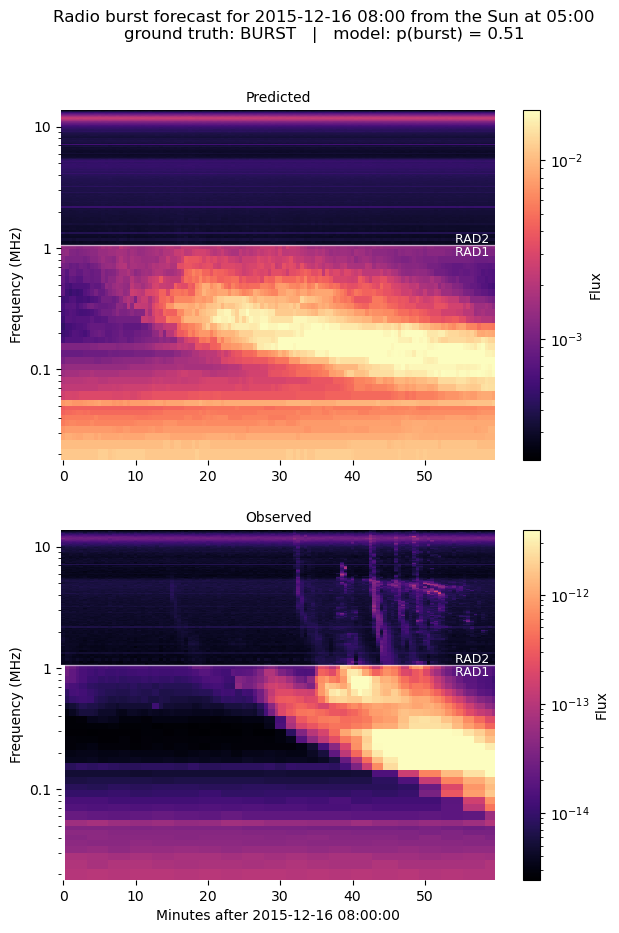

In [11]:
def plot_spectrogram(ax, spectra, minutes, frequencies_mhz, title):
    """Draw one (T, F) spectrogram on a true log-frequency axis, its own percentile-based color scale."""
    vmin = np.nanpercentile(spectra, 1)
    vmax = np.nanpercentile(spectra, 99.5)
    norm = LogNorm(vmin=max(vmin, 1e-16), vmax=vmax)
    # frequencies_mhz is non-decreasing but not unique (RAD2 pairs bins) — pcolormesh only
    # needs non-decreasing, so "auto" shading handles the repeats fine.
    mesh = ax.pcolormesh(minutes, frequencies_mhz, spectra.T,
                         norm=norm, cmap="magma", shading="auto")

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    rad1_rad2_boundary = 1.05  # MHz: RAD1 tops out at 1.04, RAD2 starts at 1.08
    ax.axhline(rad1_rad2_boundary, color="white", linewidth=1, alpha=0.6)
    ax.text(minutes[-1], rad1_rad2_boundary, "RAD1 ", color="white", ha="right", va="top", fontsize=9)
    ax.text(minutes[-1], rad1_rad2_boundary, "RAD2 ", color="white", ha="right", va="bottom", fontsize=9)

    ax.set_ylabel("Frequency (MHz)")
    ax.set_title(title, fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return mesh


# All plots from this notebook land here, relative to this notebook's own folder.
PLOTS_DIR = Path("Plots")

panels = [("Predicted", predicted_flux), ("Observed", observed_flux)]
panels = [(label, spectra) for label, spectra in panels if spectra is not None]

if not panels:
    print(f"Nothing to plot: no burst predicted (p={burst_probability:.3f}) "
          "and no catalogued window to show.")
else:
    minutes, frequencies_mhz = spectrogram_axes(
        Path(cfg.data.ds_radioburst_folder_path) / cfg.data.ds_spectra_template_file
    )

    # Stacked rows, ground truth ("Observed") below the prediction. Each panel gets its own
    # color scale and colorbar — see the markdown above for why they aren't shared.
    fig, axes = plt.subplots(len(panels), 1, figsize=(7, 5 * len(panels)), squeeze=False)
    for ax, (label, spectra) in zip(axes[:, 0], panels):
        mesh = plot_spectrogram(ax, spectra, minutes, frequencies_mhz, label)
        fig.colorbar(mesh, ax=ax, label="Flux")
    axes[-1, 0].set_xlabel(f"Minutes after {window_start}")

    # Ground truth and the model's burst probability, together in one title.
    if catalog_row is not None:
        ground_truth = "BURST" if catalog_row["burst"] else "quiet"
        truth_line = f"ground truth: {ground_truth}   |   model: p(burst) = {burst_probability:.2f}"
    else:
        truth_line = f"model: p(burst) = {burst_probability:.2f}   |   no catalogued ground truth"
    fig.suptitle(f"Radio burst forecast for {window_start:%Y-%m-%d %H:%M} "
                 f"from the Sun at {frame['timestep']:%H:%M}\n{truth_line}", fontsize=12)

    PLOTS_DIR.mkdir(exist_ok=True)
    out_path = PLOTS_DIR / f"radioburst_forecast_{window_start:%Y%m%d_%H%M%S}.png"
    fig.savefig(out_path, dpi=150)
    print(f"Saved: {out_path}")
    plt.show()

## Batch evaluation: HSS, F1, Precision, Recall

Everything above walks through one event. This section scores the same model against **every** catalogued window from `START_DATE` onward, so the four numbers below are not a single spot check.

Each catalogued window becomes one prediction: `window_start - ds_forecast_horizon` gives the frame to feed the model — the same rule `RadioBurstDSDataset` uses at training time and `find_catalog_window()` uses above — the model's probability is thresholded at `BURST_THRESHOLD`, and that call is compared to the catalog's own `burst` label.

**Two caveats.** This is expensive: each unique frame is a ~600 MB NetCDF download (cached after the first run), and the 2020-onward slice alone is 66 windows — set `max_events` to a small number first to check the loop works before running it unattended. And the train/val split in this app is a random per-sample split, not date-based, so this slice mixes windows the model was and wasn't trained on — read these numbers as a rough signal, not a clean held-out score.

Both the per-event predictions and the summary confusion matrix are saved under `Metrics/` (created if it doesn't exist), named by the checkpoint and `START_DATE`, so a batch run leaves files behind instead of only cell output — the same pattern the single-event plots use for `Plots/`. The confusion matrix is also plotted and saved there, alongside the single-event spectrogram figures.

In [12]:
START_DATE = "2020-01-01"     # <-- catalog windows on or after this date are evaluated
max_events = None                # <-- cap for a quick check; raise (or set to None) for the full slice

catalog = pd.read_csv(Path(cfg.data.ds_radioburst_folder_path) / cfg.data.ds_radioburst_index_file)
catalog[cfg.data.ds_time_column] = pd.to_datetime(catalog[cfg.data.ds_time_column])
events = catalog[catalog[cfg.data.ds_time_column] >= START_DATE].sort_values(cfg.data.ds_time_column)
if max_events is not None:
    events = events.iloc[:max_events]

print(f"Evaluating {len(events)} catalogued windows from {START_DATE} onward "
      f"({int(events['burst'].sum())} burst, {int((events['burst'] == 0).sum())} quiet).")

Evaluating 66 catalogued windows from 2020-01-01 onward (44 burst, 22 quiet).


In [13]:
horizon = pd.Timedelta(cfg.data.ds_forecast_horizon)
records = []

for _, row in events.iterrows():
    catalog_window_start = row[cfg.data.ds_time_column]
    try:
        event_frame = resolve_frame(catalog_window_start - horizon, surya_index_path)
    except ValueError:
        records.append({"window_start": catalog_window_start, "ground_truth": int(row["burst"]),
                         "probability": None, "predicted": None, "skipped": True})
        continue

    with single_frame_index(event_frame) as index_path:
        event_dataset = build_single_frame_dataset(cfg, index_path, scalers=scalers)
        event_batch = next(iter(DataLoader(event_dataset, batch_size=1)))

    result = predict_baseline(model, event_batch, cfg, scalers)   # <-- swap for Surya: predict(model, event_batch)
    probability = float(result["burst_probability"][0])
    records.append({"window_start": catalog_window_start, "ground_truth": int(row["burst"]),
                     "probability": probability, "predicted": int(probability >= BURST_THRESHOLD),
                     "skipped": False})
    print(f"{catalog_window_start}  ground truth={int(row['burst'])}  p(burst)={probability:.3f}")

results = pd.DataFrame(records)
n_skipped = int(results["skipped"].sum())
print(f"\n{n_skipped} of {len(results)} windows skipped (no Surya frame at window_start - horizon).")

2020-01-28 18:00:00  ground truth=0  p(burst)=0.576


2020-02-03 21:00:00  ground truth=0  p(burst)=0.553


2020-02-28 16:00:00  ground truth=0  p(burst)=0.577


2020-05-31 11:00:00  ground truth=0  p(burst)=0.532


2020-06-30 07:00:00  ground truth=0  p(burst)=0.500


...

2024-07-23 14:00:00  ground truth=1  p(burst)=0.566


2024-08-05 15:00:00  ground truth=1  p(burst)=0.571


2024-09-09 05:00:00  ground truth=1  p(burst)=0.487


2024-10-07 20:00:00  ground truth=1  p(burst)=0.552


2024-11-04 01:00:00  ground truth=1  p(burst)=0.499

3 of 66 windows skipped (no Surya frame at window_start - horizon).


In [14]:
scored = results[~results["skipped"]]
metrics = classification_metrics(scored["ground_truth"].to_numpy(), scored["predicted"].to_numpy())

print(f"Confusion matrix over {len(scored)} scored windows "
      f"— TP={metrics['tp']} FP={metrics['fp']} TN={metrics['tn']} FN={metrics['fn']}")
print(f"Precision: {metrics['precision']:.3f}")
print(f"Recall:    {metrics['recall']:.3f}")
print(f"F1:        {metrics['f1']:.3f}")
print(f"HSS:       {metrics['hss']:.3f}")

# Persist both the per-event predictions and the summary metrics, so a batch run leaves
# files behind instead of only cell output — named by checkpoint and date range, like Plots/.
import json

METRICS_DIR = Path("Metrics")
METRICS_DIR.mkdir(exist_ok=True)
run_tag = f"{Path(ckpt_path).stem}_{START_DATE}"

events_path = METRICS_DIR / f"radioburst_batch_events_{run_tag}.csv"
results.to_csv(events_path, index=False)

summary_path = METRICS_DIR / f"radioburst_batch_summary_{run_tag}.json"
summary = {
    "checkpoint": str(ckpt_path),
    "start_date": START_DATE,
    "max_events": max_events,
    "burst_threshold": BURST_THRESHOLD,
    "n_events": len(events),
    "n_scored": len(scored),
    "n_skipped": int(results["skipped"].sum()),
    **metrics,
}
summary_path.write_text(json.dumps(summary, indent=2, default=str))

print(f"Saved: {events_path}")
print(f"Saved: {summary_path}")

Confusion matrix over 63 scored windows — TP=29 FP=19 TN=2 FN=13
Precision: 0.604
Recall:    0.690
F1:        0.644
HSS:       -0.231
Saved: Metrics/radioburst_batch_events_baseline-epoch=00-val_loss_burst_bce=0.6657_2020-01-01.csv
Saved: Metrics/radioburst_batch_summary_baseline-epoch=00-val_loss_burst_bce=0.6657_2020-01-01.json


In [ ]:
def plot_confusion_matrix(metrics, title):
    """Draw a 2x2 quiet/burst confusion matrix with counts annotated."""
    cm = np.array([[metrics["tn"], metrics["fp"]],
                   [metrics["fn"], metrics["tp"]]])
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    labels = ["quiet", "burst"]
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_title(title, fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
    fig.colorbar(im, ax=ax, label="Count")
    fig.tight_layout()
    return fig


fig = plot_confusion_matrix(metrics, f"Baseline confusion matrix\n{Path(ckpt_path).stem}")
PLOTS_DIR.mkdir(exist_ok=True)
out_path = PLOTS_DIR / f"radioburst_confusion_matrix_{Path(ckpt_path).stem}_{START_DATE}.png"
fig.savefig(out_path, dpi=150)
print(f"Saved: {out_path}")
plt.show()

## Now with the fine-tuned Surya model

Everything above used the linear baseline. This repeats the single-event walkthrough with the fine-tuned checkpoint from notebook 2 — `load_finetuned_burst_model()` and `predict()`, the two swaps called out above — reusing the exact same `frame`, `batch`, `window_start`, `catalog_row` and `observed_flux` already computed, so only the model and the reading of its output differ.

Two things differ from the baseline. The checkpoint is a `finetune-*.ckpt` (~1.8 GB — the whole backbone, not just a head — so `load_finetuned_burst_model()` rebuilds the architecture, re-applies LoRA, then loads strictly). And its predicted spectrogram is reconstructed through its own `spectra_normalizer`, loaded from the fine-tuning checkpoint's sidecar just below — the same kind of normalizer already used for the baseline above, reloaded (or refit) against this checkpoint instead.

In [15]:
finetune_ckpt_path = latest_checkpoint(cfg.output.ckpt_dir, pattern="finetune-*.ckpt")
print(f"Fine-tuned checkpoint: {finetune_ckpt_path}")

finetuned_model = load_finetuned_burst_model(cfg, finetune_ckpt_path)
device = next(finetuned_model.parameters()).device
print(f"Model on {device}, eval mode: {not finetuned_model.training}")

Fine-tuned checkpoint: checkpoints/finetune-epoch=07-val_loss=0.8718.ckpt


Applying PEFT LoRA: r=8, alpha=8, dropout=0.1, modules=['fc1', 'fc2', 'attn.qkv', 'attn.proj']
[LoRA] Adapted modules (36):
[LoRA]   backbone.backbone.blocks_attention.0.attn.proj
[LoRA]   backbone.backbone.blocks_attention.0.attn.qkv
[LoRA]   backbone.backbone.blocks_attention.0.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.0.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.1.attn.proj
[LoRA]   backbone.backbone.blocks_attention.1.attn.qkv
[LoRA]   backbone.backbone.blocks_attention.1.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.1.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.2.attn.proj
[LoRA]   backbone.backbone.blocks_attention.2.attn.qkv
[LoRA]   backbone.backbone.blocks_attention.2.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.2.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.3.attn.proj
[LoRA]   backbone.backbone.blocks_attention.3.attn.qkv
[LoRA]   backbone.backbone.blocks_attention.3.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.3.mlp.fc2


Model on cuda:0, eval mode: True


In [16]:
finetuned_result = predict(finetuned_model, batch)
finetuned_burst_probability = float(finetuned_result["burst_probability"][0])
finetuned_is_burst = finetuned_burst_probability >= BURST_THRESHOLD

print(f"Burst probability: {finetuned_burst_probability:.3f}")
print(f"Prediction:        {'BURST' if finetuned_is_burst else 'no burst'} "
      f"in {window_start} to {window_start + pd.Timedelta('1h')}")

Burst probability: 0.849
Prediction:        BURST in 2015-12-16 08:00:00 to 2015-12-16 09:00:00


In [17]:
spectra_normalizer = load_spectra_normalizer(cfg, finetune_ckpt_path)

if finetuned_is_burst:
    finetuned_predicted_flux = spectra_normalizer.inverse(finetuned_result["spectra"][0])
    print(f"Predicted spectrogram: {finetuned_predicted_flux.shape}, "
          f"flux {finetuned_predicted_flux.min():.2e} to {finetuned_predicted_flux.max():.2e}")
    if observed_flux is not None:
        ratio = finetuned_predicted_flux.max() / np.nanmax(observed_flux)
        print(f"Peak: predicted {finetuned_predicted_flux.max():.2e} vs "
              f"observed {np.nanmax(observed_flux):.2e}  ({ratio:.2g}x)")
else:
    finetuned_predicted_flux = None
    print(f"No burst predicted (p={finetuned_burst_probability:.3f}) — no predicted spectrogram.")

Predicted spectrogram: (120, 288), flux 5.66e-16 to 5.09e-15
Peak: predicted 5.09e-15 vs observed 1.57e-11  (0.00032x)


Saved: Plots/radioburst_forecast_finetuned_20151216_080000.png


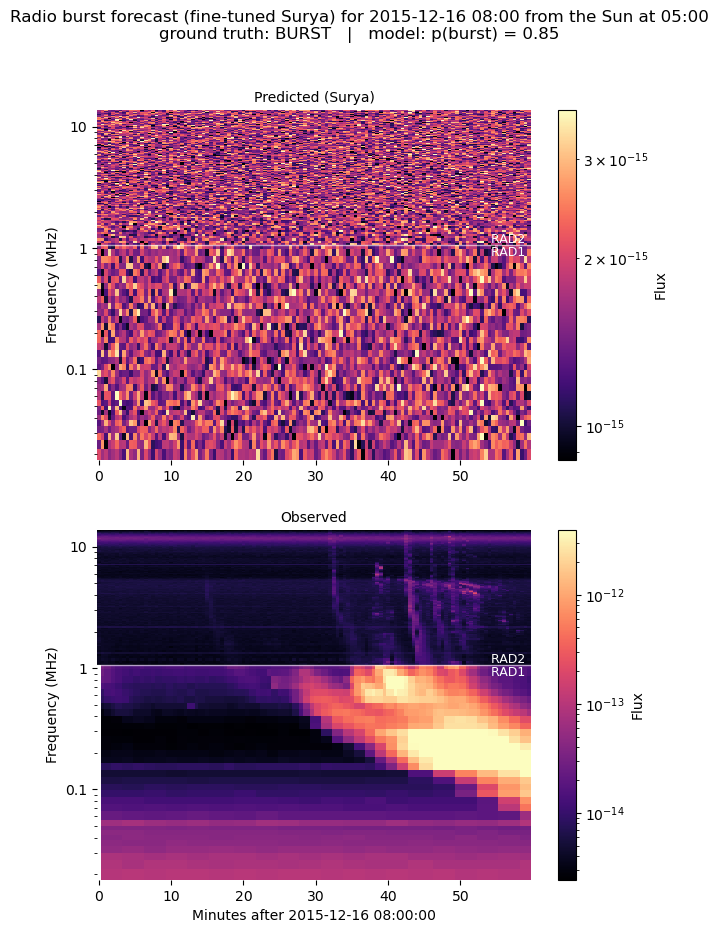

In [18]:
minutes, frequencies_mhz = spectrogram_axes(
    Path(cfg.data.ds_radioburst_folder_path) / cfg.data.ds_spectra_template_file
)

finetuned_panels = [("Predicted (Surya)", finetuned_predicted_flux), ("Observed", observed_flux)]
finetuned_panels = [(label, spectra) for label, spectra in finetuned_panels if spectra is not None]

if not finetuned_panels:
    print(f"Nothing to plot: no burst predicted (p={finetuned_burst_probability:.3f}) "
          "and no catalogued window to show.")
else:
    fig, axes = plt.subplots(len(finetuned_panels), 1, figsize=(7, 5 * len(finetuned_panels)), squeeze=False)
    for ax, (label, spectra) in zip(axes[:, 0], finetuned_panels):
        mesh = plot_spectrogram(ax, spectra, minutes, frequencies_mhz, label)
        fig.colorbar(mesh, ax=ax, label="Flux")
    axes[-1, 0].set_xlabel(f"Minutes after {window_start}")

    if catalog_row is not None:
        ground_truth = "BURST" if catalog_row["burst"] else "quiet"
        truth_line = f"ground truth: {ground_truth}   |   model: p(burst) = {finetuned_burst_probability:.2f}"
    else:
        truth_line = f"model: p(burst) = {finetuned_burst_probability:.2f}   |   no catalogued ground truth"
    fig.suptitle(f"Radio burst forecast (fine-tuned Surya) for {window_start:%Y-%m-%d %H:%M} "
                 f"from the Sun at {frame['timestep']:%H:%M}\n{truth_line}", fontsize=12)

    PLOTS_DIR.mkdir(exist_ok=True)
    out_path = PLOTS_DIR / f"radioburst_forecast_finetuned_{window_start:%Y%m%d_%H%M%S}.png"
    fig.savefig(out_path, dpi=150)
    print(f"Saved: {out_path}")
    plt.show()

## Batch evaluation for the fine-tuned model

Repeats the batch-evaluation loop above with the fine-tuned model, over the exact same `events` slice (`START_DATE`, `max_events`) computed earlier, so the two are directly comparable — only `predict_baseline` swaps for `predict()`, the same swap used in the single-event walkthrough. Results are kept in their own variables (`finetuned_records`, `finetuned_results`, `finetuned_metrics`) so they don't overwrite the baseline's, and are saved under `Metrics/` the same way, named by the fine-tuned checkpoint — including its own confusion matrix plot under `Plots/`, reusing the `plot_confusion_matrix()` helper defined above.

In [19]:
finetuned_records = []

for _, row in events.iterrows():
    catalog_window_start = row[cfg.data.ds_time_column]
    try:
        event_frame = resolve_frame(catalog_window_start - horizon, surya_index_path)
    except ValueError:
        finetuned_records.append({"window_start": catalog_window_start, "ground_truth": int(row["burst"]),
                                   "probability": None, "predicted": None, "skipped": True})
        continue

    with single_frame_index(event_frame) as index_path:
        event_dataset = build_single_frame_dataset(cfg, index_path, scalers=scalers)
        event_batch = next(iter(DataLoader(event_dataset, batch_size=1)))

    event_result = predict(finetuned_model, event_batch)
    probability = float(event_result["burst_probability"][0])
    finetuned_records.append({"window_start": catalog_window_start, "ground_truth": int(row["burst"]),
                               "probability": probability, "predicted": int(probability >= BURST_THRESHOLD),
                               "skipped": False})
    print(f"{catalog_window_start}  ground truth={int(row['burst'])}  p(burst)={probability:.3f}")

finetuned_results = pd.DataFrame(finetuned_records)
n_skipped = int(finetuned_results["skipped"].sum())
print(f"\n{n_skipped} of {len(finetuned_results)} windows skipped (no Surya frame at window_start - horizon).")

2020-01-28 18:00:00  ground truth=0  p(burst)=0.790


2020-02-03 21:00:00  ground truth=0  p(burst)=0.705


2020-02-28 16:00:00  ground truth=0  p(burst)=0.899


2020-05-31 11:00:00  ground truth=0  p(burst)=0.808


2020-06-30 07:00:00  ground truth=0  p(burst)=0.871


...

2024-07-23 14:00:00  ground truth=1  p(burst)=0.895


2024-08-05 15:00:00  ground truth=1  p(burst)=0.885


2024-09-09 05:00:00  ground truth=1  p(burst)=0.905


2024-10-07 20:00:00  ground truth=1  p(burst)=0.903


2024-11-04 01:00:00  ground truth=1  p(burst)=0.901

3 of 66 windows skipped (no Surya frame at window_start - horizon).


In [20]:
finetuned_scored = finetuned_results[~finetuned_results["skipped"]]
finetuned_metrics = classification_metrics(
    finetuned_scored["ground_truth"].to_numpy(), finetuned_scored["predicted"].to_numpy()
)

print(f"Confusion matrix over {len(finetuned_scored)} scored windows "
      f"— TP={finetuned_metrics['tp']} FP={finetuned_metrics['fp']} "
      f"TN={finetuned_metrics['tn']} FN={finetuned_metrics['fn']}")
print(f"Precision: {finetuned_metrics['precision']:.3f}")
print(f"Recall:    {finetuned_metrics['recall']:.3f}")
print(f"F1:        {finetuned_metrics['f1']:.3f}")
print(f"HSS:       {finetuned_metrics['hss']:.3f}")

# Same persistence pattern as the baseline's batch cell above, under its own filename.
import json

METRICS_DIR = Path("Metrics")
METRICS_DIR.mkdir(exist_ok=True)
finetuned_run_tag = f"{Path(finetune_ckpt_path).stem}_{START_DATE}"

finetuned_events_path = METRICS_DIR / f"radioburst_batch_events_{finetuned_run_tag}.csv"
finetuned_results.to_csv(finetuned_events_path, index=False)

finetuned_summary_path = METRICS_DIR / f"radioburst_batch_summary_{finetuned_run_tag}.json"
finetuned_summary = {
    "checkpoint": str(finetune_ckpt_path),
    "start_date": START_DATE,
    "max_events": max_events,
    "burst_threshold": BURST_THRESHOLD,
    "n_events": len(events),
    "n_scored": len(finetuned_scored),
    "n_skipped": int(finetuned_results["skipped"].sum()),
    **finetuned_metrics,
}
finetuned_summary_path.write_text(json.dumps(finetuned_summary, indent=2, default=str))

print(f"Saved: {finetuned_events_path}")
print(f"Saved: {finetuned_summary_path}")

Confusion matrix over 63 scored windows — TP=42 FP=21 TN=0 FN=0
Precision: 0.667
Recall:    1.000
F1:        0.800
HSS:       0.000
Saved: Metrics/radioburst_batch_events_finetune-epoch=07-val_loss=0.8718_2020-01-01.csv
Saved: Metrics/radioburst_batch_summary_finetune-epoch=07-val_loss=0.8718_2020-01-01.json


In [ ]:
fig = plot_confusion_matrix(finetuned_metrics, f"Fine-tuned confusion matrix\n{Path(finetune_ckpt_path).stem}")
PLOTS_DIR.mkdir(exist_ok=True)
out_path = PLOTS_DIR / f"radioburst_confusion_matrix_{Path(finetune_ckpt_path).stem}_{START_DATE}.png"
fig.savefig(out_path, dpi=150)
print(f"Saved: {out_path}")
plt.show()

## Before you believe any of this

The pipeline is finished; the science is not. Read these before quoting a number from this notebook.

- **The baseline is barely trained.** The catalog holds 170 windows (85 burst, 85 quiet), which matched 116 training and 7 validation windows. In the latest baseline run the validation F1 was **0.0** and `val_loss_bce` sat at 0.6986 (that term is logged as `val_loss_burst_bce` since the loss weights were split out) — that is a model predicting essentially one class. Read its plot as a demonstration of the pipeline, not as a forecast.
- **Both models' batch metrics come from the same 66-window, 2020-onward slice** (see `Metrics/` for both), which makes them directly comparable to each other — but the slice itself is still small and not date-based (only 7 true validation windows), so read a difference between the two as suggestive, not decisive.
- **`latest_checkpoint()` picks the newest file, not the best one**, for both models — check the filename's `val_loss` before trusting a specific run; the checkpoints directory holds several of each.
- **The predicted shape is fixed for the baseline** — it scales one median template, so the only thing it predicts about the spectrogram is its brightness. The fine-tuned head's `head_spectra` is a learned rank-32 basis, so its shape *can* vary between predictions, but with 7 validation windows there's no way to tell whether that variation tracks anything real.
- **Ground truth exists for 170 windows only.** Any other timestamp gives a prediction nobody can check.
- **The threshold is a default,** not an operating point chosen from a precision/recall curve.
- **One frame, no history.** `time_delta_input_minutes: [0]` means both models see a single image stack, not a sequence.
- **The batch HSS/F1/Precision/Recall for both models are still small-sample and not a clean held-out score.** Even the full 2020-onward slice is ~66 catalogued windows (44 burst, 22 quiet), some of which are skipped when no Surya frame exists at `window_start - ds_forecast_horizon`; and the train/val split in this app is a random per-sample split, not date-based, so the slice mixes windows each model was and wasn't trained on.

## Conclusion

Dataset, baseline, fine-tuning, single-event and now batch prediction from both models: the loop is closed end to end, and `Metrics/` holds both models' numbers on the same 2020-onward slice for direct comparison. What's left is scale — with only 7 true validation windows, growing the catalog is what would actually make the difference between the two models' numbers mean something.